### **Imports**

In [1]:
import numpy as np 
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/riyagarg0314/discord-github-ecosystem-2026/discord_ecosystem_2026.csv")

In [3]:
df.shape

(1735, 26)

In [4]:
df.describe

<bound method NDFrame.describe of               id                           name  \
0     1147094660                        nanobot   
1      577603990                 Open-Assistant   
2       40484398                     discord.js   
3      575321313                        LangBot   
4       41179827                     discord.py   
...          ...                            ...   
1730  1327717969  discord-server-booster-client   
1731   457280566                         Shorty   
1732   259873933                       pyke-bot   
1733  1040399166                    pipewire-rs   
1734  1218343045                    arborium-rt   

                                            full_name              owner  \
0                                       HKUDS/nanobot              HKUDS   
1                             LAION-AI/Open-Assistant           LAION-AI   
2                                discordjs/discord.js          discordjs   
3                                 langbot-app/Lan

In [5]:
df.head()

,id,name,full_name,owner,owner_type,is_official_discord,description,html_url,homepage,stars,...,topics,queried_topic,created_at,updated_at,pushed_at,repo_age_days,days_since_last_push,size_kb,is_fork,archived
0,1147094660,nanobot,HKUDS/nanobot,HKUDS,Organization,False,"Ultra-lightweight, open-source, self-hosted pe...",https://github.com/HKUDS/nanobot,https://nanobot.wiki,46967,...,agent-framework;ai-agent;ai-agents;chatbot;cha...,discord-bot,2026-02-01 07:16:15+00:00,2026-08-14 07:32:34+00:00,2026-08-14 03:22:22+00:00,194,0,57053,False,False
1,577603990,Open-Assistant,LAION-AI/Open-Assistant,LAION-AI,Organization,False,OpenAssistant is a chat-based assistant that u...,https://github.com/LAION-AI/Open-Assistant,https://open-assistant.io,37408,...,ai;assistant;chatgpt;discord-bot;language-mode...,discord-bot,2022-12-13 05:24:17+00:00,2026-08-14 01:26:24+00:00,2024-08-17 01:55:35+00:00,1340,727,35477,False,False
2,40484398,discord.js,discordjs/discord.js,discordjs,Organization,False,A powerful JavaScript library for interacting ...,https://github.com/discordjs/discord.js,https://discord.js.org,26783,...,bot;discord;discord-api;discord-bot;discord-se...,discord-bot,2015-08-10 13:36:26+00:00,2026-08-14 02:37:51+00:00,2026-08-13 19:10:25+00:00,4021,0,68288,False,False
3,575321313,LangBot,langbot-app/LangBot,langbot-app,Organization,False,Production-grade platform for building agentic...,https://github.com/langbot-app/LangBot,https://langbot.app,17404,...,agent;coze;deepseek;dify;dingtalk;discord;feis...,discord-bot-broad,2022-12-07 08:48:02+00:00,2026-08-14 07:05:13+00:00,2026-08-13 17:11:16+00:00,1345,0,55675,False,False
4,41179827,discord.py,Rapptz/discord.py,Rapptz,User,False,An API wrapper for Discord written in Python.,https://github.com/Rapptz/discord.py,http://discordpy.rtfd.org/en/latest,16139,...,bot;discord;discord-api;discord-bot;discord-py...,discord-bot,2015-08-21 22:19:08+00:00,2026-08-13 23:41:58+00:00,2026-07-27 18:33:15+00:00,4010,17,23106,False,False


In [6]:
df.isna().sum()

id                         0
name                       0
full_name                  0
owner                      0
owner_type                 0
is_official_discord        0
description               38
html_url                   0
homepage                1111
stars                      0
forks                      0
watchers                   0
open_issues                0
stars_per_day              0
language                  59
license                  372
topics                    84
queried_topic              0
created_at                 0
updated_at                 0
pushed_at                  0
repo_age_days              0
days_since_last_push       0
size_kb                    0
is_fork                    0
archived                   0
dtype: int64

### The 'homepage' attribute is having the most null values making it clear that many of the entires here in discords don't have a home page 

In [7]:
df['homepage'].nunique()

616

In [8]:
df[df['description'].isnull()]

,id,name,full_name,owner,owner_type,is_official_discord,description,html_url,homepage,stars,...,topics,queried_topic,created_at,updated_at,pushed_at,repo_age_days,days_since_last_push,size_kb,is_fork,archived
35,298235909,brightid-discord-bot,ShenaniganDApp/brightid-discord-bot,ShenaniganDApp,Organization,False,NaN,https://github.com/ShenaniganDApp/brightid-dis...,https://bot.brightid.org,1779,...,NaN,discord-bot-broad,2020-09-24 09:48:45+00:00,2026-08-10 06:06:21+00:00,2024-05-11 03:33:34+00:00,2149,825,2885,False,False
63,97152773,discord-rpc,discord/discord-rpc,discord,Organization,True,NaN,https://github.com/discord/discord-rpc,https://discordapp.com/developers,1172,...,NaN,official-discord-org,2017-07-13 18:20:34+00:00,2026-08-14 01:21:19+00:00,2024-06-13 08:48:00+00:00,3318,791,2810,False,False
242,140887545,PluralKit,PluralKit/PluralKit,PluralKit,Organization,False,NaN,https://github.com/PluralKit/PluralKit,https://pluralkit.me/,326,...,discord-bot;hacktoberfest,discord-bot,2018-07-13 19:52:35+00:00,2026-08-10 20:55:38+00:00,2026-08-10 22:08:21+00:00,2953,3,13410,False,False
360,291714389,Bot,Discord-TTS/Bot,Discord-TTS,Organization,False,NaN,https://github.com/Discord-TTS/Bot,https://discord.gg/zWPWwQC,226,...,NaN,discord-bot-broad,2020-08-31 12:51:42+00:00,2026-08-13 07:26:33+00:00,2026-06-23 20:53:49+00:00,2173,51,2106,False,False
420,1288647244,discord-server-booster-2026,volshebreek-morty/discord-server-booster-2026,volshebreek-morty,User,False,NaN,https://github.com/volshebreek-morty/discord-s...,NaN,175,...,discord;discord-boost-bot;discord-boost-tool;d...,discord-selfbot,2026-07-03 20:18:45+00:00,2026-08-12 15:54:06+00:00,2026-07-03 20:18:57+00:00,41,41,3,False,False
457,574605919,linked-roles-sample,discord/linked-roles-sample,discord,Organization,True,NaN,https://github.com/discord/linked-roles-sample,NaN,151,...,samples,official-discord-org,2022-12-05 17:16:43+00:00,2026-07-24 12:20:54+00:00,2026-02-16 19:14:34+00:00,1347,178,2988,False,False
471,116887421,Discord.js-Bot-Development,The-SourceCode/Discord.js-Bot-Development,The-SourceCode,User,False,NaN,https://github.com/The-SourceCode/Discord.js-B...,NaN,142,...,discord;discord-js;discordjs;discordjs-bot,discordjs,2018-01-10 00:33:56+00:00,2026-07-31 12:16:49+00:00,2022-05-16 14:26:51+00:00,3138,1550,68,False,False
647,499900537,discord-server-booster,qoft/discord-server-booster,qoft,User,False,NaN,https://github.com/qoft/discord-server-booster,NaN,75,...,boost;discord;discord-boost;discord-boost-tool...,discord-server,2022-06-04 18:01:11+00:00,2026-08-09 07:21:08+00:00,2023-03-30 18:53:41+00:00,1531,1232,17,False,False
913,688984095,memory_size,discord/memory_size,discord,Organization,True,NaN,https://github.com/discord/memory_size,NaN,38,...,NaN,official-discord-org,2023-09-08 14:21:16+00:00,2025-05-28 10:19:27+00:00,2023-09-12 03:12:54+00:00,1070,1067,8,False,False
946,110470031,MediaButler,MediaButler/MediaButler,MediaButler,Organization,False,NaN,https://github.com/MediaButler/MediaButler,NaN,34,...,bot;discord;discord-bot;discord-server;docker;...,discord-server,2017-11-12 21:18:08+00:00,2023-11-10 15:43:39+00:00,2018-12-22 00:34:54+00:00,3196,2792,4442,False,True


In [9]:
# Fill text/categorical columns
text_cols = [
    "description",
    "homepage",
    "language",
    "license",
    "topics"
]

for col in text_cols:
    df[col] = df[col].fillna("Unknown")

#### This filling technique just appends a no. of 'Unknown' values in the dataframe though it is better than having null values instead as no mean, median and mode or other techniques apply here.

In [10]:
df.isna().sum()

id                      0
name                    0
full_name               0
owner                   0
owner_type              0
is_official_discord     0
description             0
html_url                0
homepage                0
stars                   0
forks                   0
watchers                0
open_issues             0
stars_per_day           0
language                0
license                 0
topics                  0
queried_topic           0
created_at              0
updated_at              0
pushed_at               0
repo_age_days           0
days_since_last_push    0
size_kb                 0
is_fork                 0
archived                0
dtype: int64

In [11]:
df.duplicated

<bound method DataFrame.duplicated of               id                           name  \
0     1147094660                        nanobot   
1      577603990                 Open-Assistant   
2       40484398                     discord.js   
3      575321313                        LangBot   
4       41179827                     discord.py   
...          ...                            ...   
1730  1327717969  discord-server-booster-client   
1731   457280566                         Shorty   
1732   259873933                       pyke-bot   
1733  1040399166                    pipewire-rs   
1734  1218343045                    arborium-rt   

                                            full_name              owner  \
0                                       HKUDS/nanobot              HKUDS   
1                             LAION-AI/Open-Assistant           LAION-AI   
2                                discordjs/discord.js          discordjs   
3                                 langbot-app

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns

Index(['id', 'name', 'full_name', 'owner', 'owner_type', 'is_official_discord',
       'description', 'html_url', 'homepage', 'stars', 'forks', 'watchers',
       'open_issues', 'stars_per_day', 'language', 'license', 'topics',
       'queried_topic', 'created_at', 'updated_at', 'pushed_at',
       'repo_age_days', 'days_since_last_push', 'size_kb', 'is_fork',
       'archived'],
      dtype='object')

### Official vs UnofficiaL DISCORD

<Axes: xlabel='is_official_discord'>

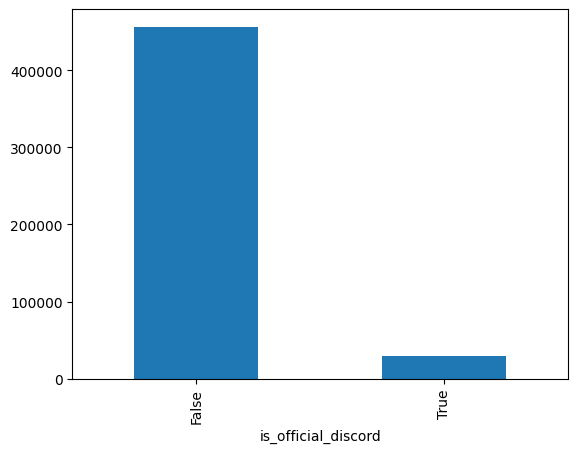

In [14]:
df.groupby('is_official_discord')['stars'].sum().plot(kind='bar')

### Top 20 repos

In [15]:
df.nlargest(20, 'stars')[['full_name','is_official_discord','stars','language']]

,full_name,is_official_discord,stars,language
0,HKUDS/nanobot,False,46967,Python
1,LAION-AI/Open-Assistant,False,37408,Python
2,discordjs/discord.js,False,26783,TypeScript
3,langbot-app/LangBot,False,17404,Python
4,Rapptz/discord.py,False,16139,Python
5,discord/discord-api-docs,True,6459,MDX
6,codebymitch/TitanBot,False,6404,JavaScript
7,bwmarrin/discordgo,False,5971,Go
8,jagrosh/MusicBot,False,5753,Java
9,ayn2op/discordo,False,5730,Go


### Most used language 

<Axes: ylabel='language'>

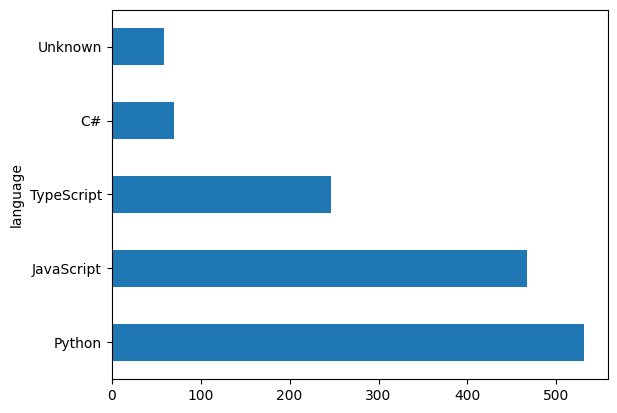

In [16]:
df['language'].value_counts().head().plot(kind='barh')

### Community libraries

In [17]:
libraries = df[df['name'].isin(['discord.js','discord.py','discordgo','discordo','discordrb'])]
libraries[['name','stars','forks','language']]

,name,stars,forks,language
2,discord.js,26783,4074,TypeScript
4,discord.py,16139,3927,Python
7,discordgo,5971,926,Go
9,discordo,5730,222,Go
111,discordrb,692,149,Ruby


### Repository age distribution

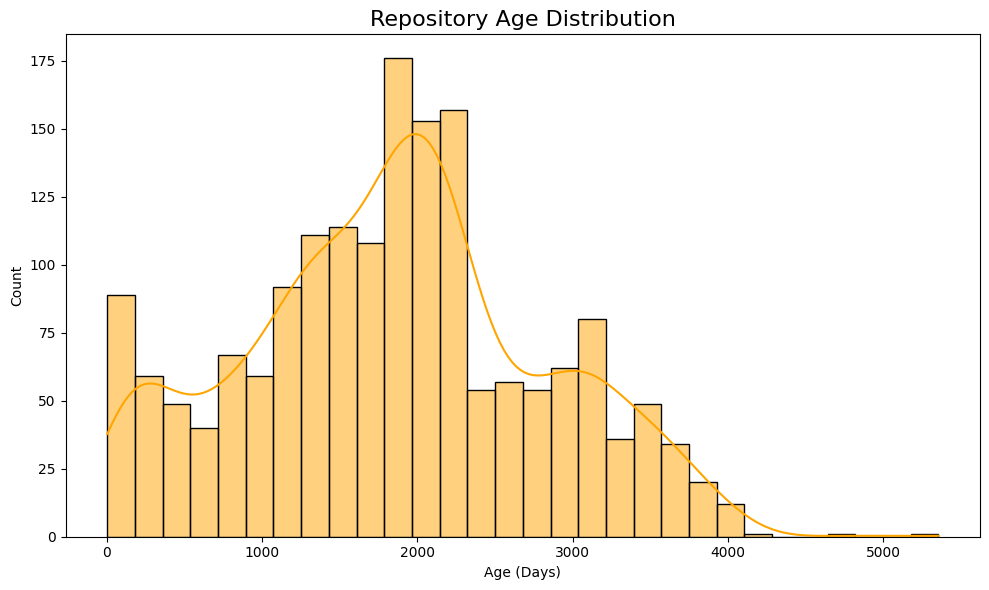

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df["repo_age_days"], bins=30, kde=True, color="orange")
plt.title("Repository Age Distribution", fontsize=16)
plt.xlabel("Age (Days)")
plt.tight_layout()
plt.show()

### License Distribution

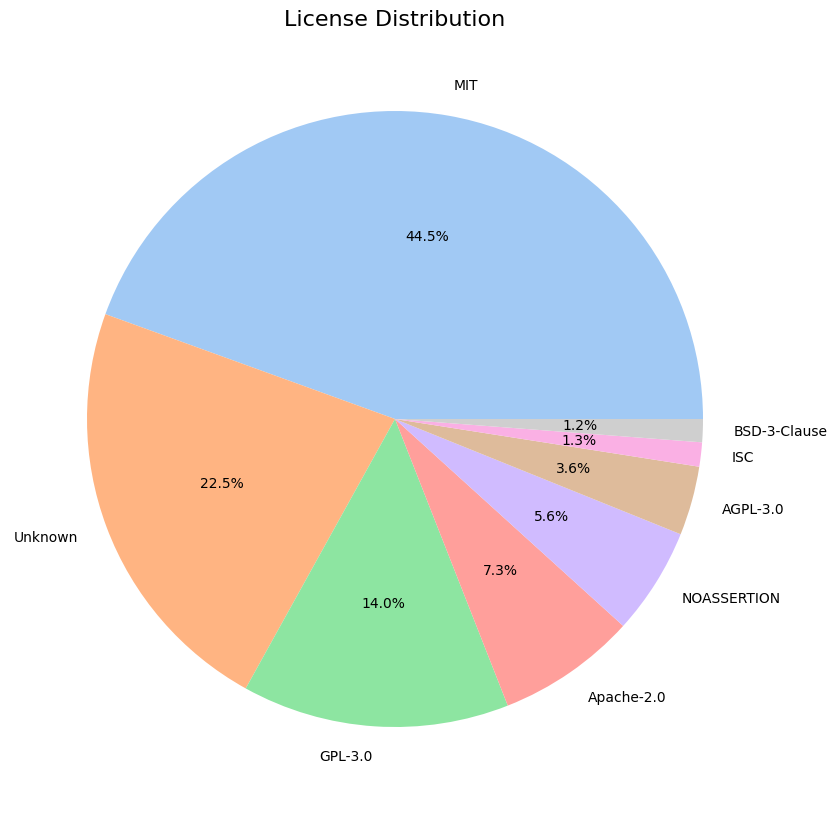

In [19]:
top_license = df["license"].value_counts().head(8)

plt.figure(figsize=(10, 10))
plt.pie(
    top_license.values,
    labels=top_license.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel")
)
plt.title("License Distribution", fontsize=16)
plt.show()

### Stars per day 


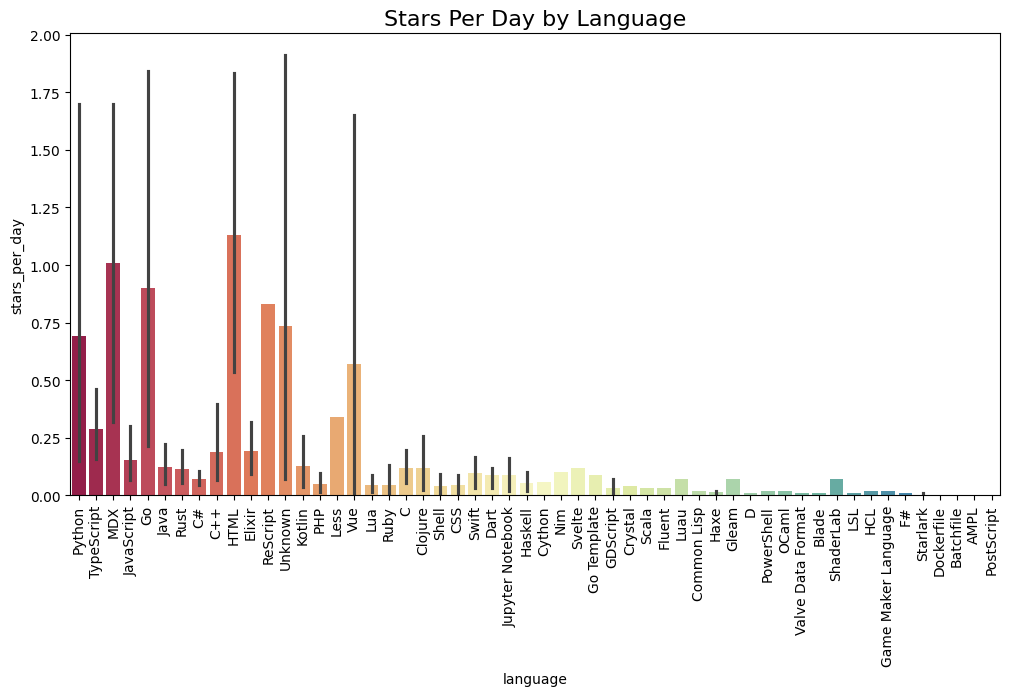

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x="language",
    y="stars_per_day",
    hue="language",
    palette="Spectral",
    legend=False
)
plt.title("Stars Per Day by Language", fontsize=16)
plt.xticks(rotation=90)
plt.show()

### Correlation heatmap

In [21]:
numeric_cols = [
    "stars", "forks", "watchers", "open_issues",
    "stars_per_day", "repo_age_days",
    "days_since_last_push", "size_kb"
]

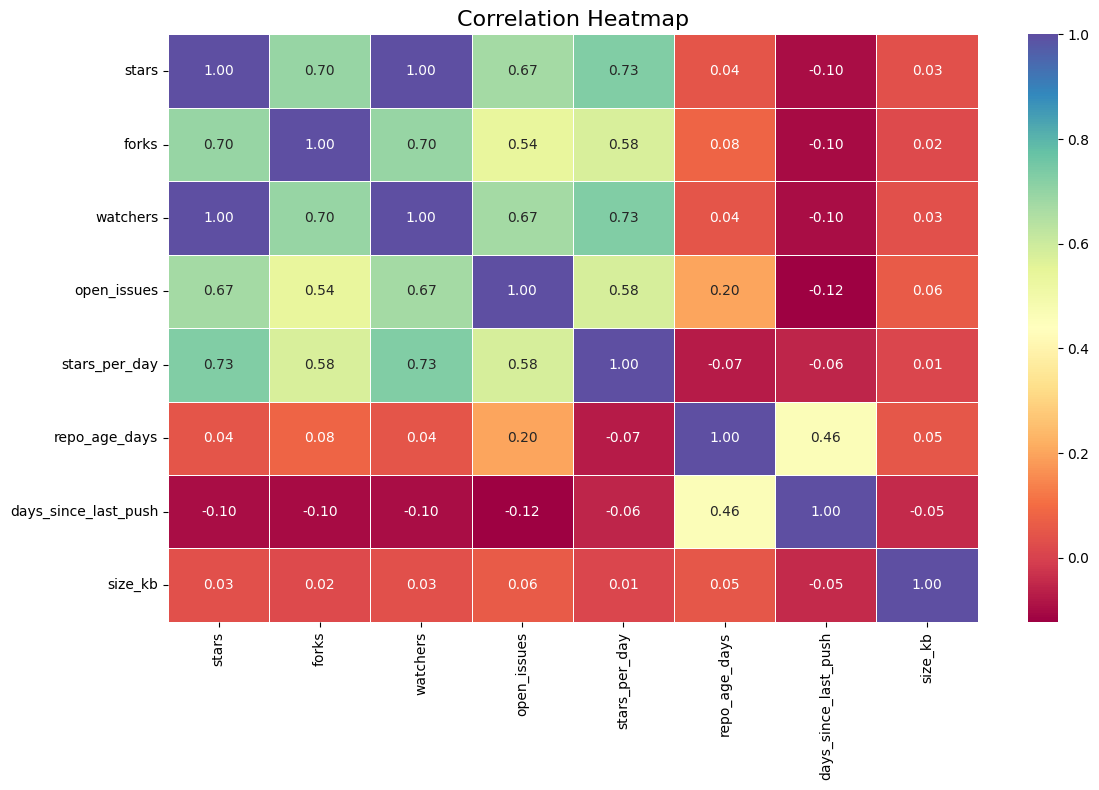

In [22]:
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Spectral",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

### If you like my work , Please Upvote !